# Satellite Image Classification


In [1]:
!pip install -q torchinfo torchview

In [56]:
import os
import time
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, Dataset

import torchvision
from torchvision import transforms, datasets, models
from transformers import CLIPProcessor, CLIPModel

from torchinfo import summary
from torchview import draw_graph
from IPython.display import Image, display

from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE

from collections import Counter, defaultdict
from tqdm import tqdm

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
def reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed}")


reproducibility()

Random seed set to 42


## 0: Dataset and Preprocessing


In [6]:
base_transform = transforms.Compose([transforms.ToTensor()])

eurosat_data = datasets.EuroSAT(root="./data", download=True, transform=base_transform)

100%|██████████| 94.3M/94.3M [00:00<00:00, 264MB/s] 


In [7]:
num_images = len(eurosat_data)
class_names = eurosat_data.classes
num_classes = len(eurosat_data.classes)
img_shape = eurosat_data[0][0].shape

print(f"Total images: {num_images}")
print(f"Total classes: {num_classes}")
print(f"Classes: {class_names}")
print(f"Image shape: {img_shape}")

Total images: 27000
Total classes: 10
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Image shape: torch.Size([3, 64, 64])


In [ ]:
train_transform = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomChoice(
            [
                transforms.RandomRotation((0, 0)),
                transforms.RandomRotation((90, 90)),
                transforms.RandomRotation((180, 180)),
                transforms.RandomRotation((270, 270)),
            ]
        ),
        transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

val_test_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

In [10]:
class_indices = defaultdict(list)

for idx, (_, label) in enumerate(eurosat_data):
    class_indices[label].append(idx)

train_full_idx = []
train_10shot_idx = []
train_5shot_idx = []
val_idx = []
test_idx = []

for label, indices in class_indices.items():
    random.shuffle(indices)
    n = len(indices)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    train_indices = indices[:n_train]
    val_indices = indices[n_train : n_train + n_val]
    test_indices = indices[n_train + n_val :]
    train_full_idx.extend(train_indices)
    val_idx.extend(val_indices)
    test_idx.extend(test_indices)
    train_10shot_idx.extend(train_indices[:10])
    train_5shot_idx.extend(train_indices[:5])

train_full = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform),
    train_full_idx,
)
train_10shot = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform),
    train_10shot_idx,
)
train_5shot = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform),
    train_5shot_idx,
)
val_set = Subset(
    datasets.EuroSAT(root="./data", transform=val_test_transform),
    val_idx,
)
test_set = Subset(
    datasets.EuroSAT(root="./data", transform=val_test_transform),
    test_idx,
)

splits = {
    "Train full": train_full,
    "Train 10-shot": train_10shot,
    "Train 5-shot": train_5shot,
    "Validation": val_set,
    "Test": test_set,
}

for name, split in splits.items():
    labels = [label for _, label in split]
    counts = Counter(labels)
    print(f"\n{name}")
    print(f"Total samples: {len(split)}")
    for cls_id, cls_name in enumerate(class_names):
        print(f"    {cls_name}: {counts.get(cls_id, 0)}")


Train full
Total samples: 18900
    AnnualCrop: 2100
    Forest: 2100
    HerbaceousVegetation: 2100
    Highway: 1750
    Industrial: 1750
    Pasture: 1400
    PermanentCrop: 1750
    Residential: 2100
    River: 1750
    SeaLake: 2100

Train 10-shot
Total samples: 100
    AnnualCrop: 10
    Forest: 10
    HerbaceousVegetation: 10
    Highway: 10
    Industrial: 10
    Pasture: 10
    PermanentCrop: 10
    Residential: 10
    River: 10
    SeaLake: 10

Train 5-shot
Total samples: 50
    AnnualCrop: 5
    Forest: 5
    HerbaceousVegetation: 5
    Highway: 5
    Industrial: 5
    Pasture: 5
    PermanentCrop: 5
    Residential: 5
    River: 5
    SeaLake: 5

Validation
Total samples: 4050
    AnnualCrop: 450
    Forest: 450
    HerbaceousVegetation: 450
    Highway: 375
    Industrial: 375
    Pasture: 300
    PermanentCrop: 375
    Residential: 450
    River: 375
    SeaLake: 450

Test
Total samples: 4050
    AnnualCrop: 450
    Forest: 450
    HerbaceousVegetation: 450
    Highway: 

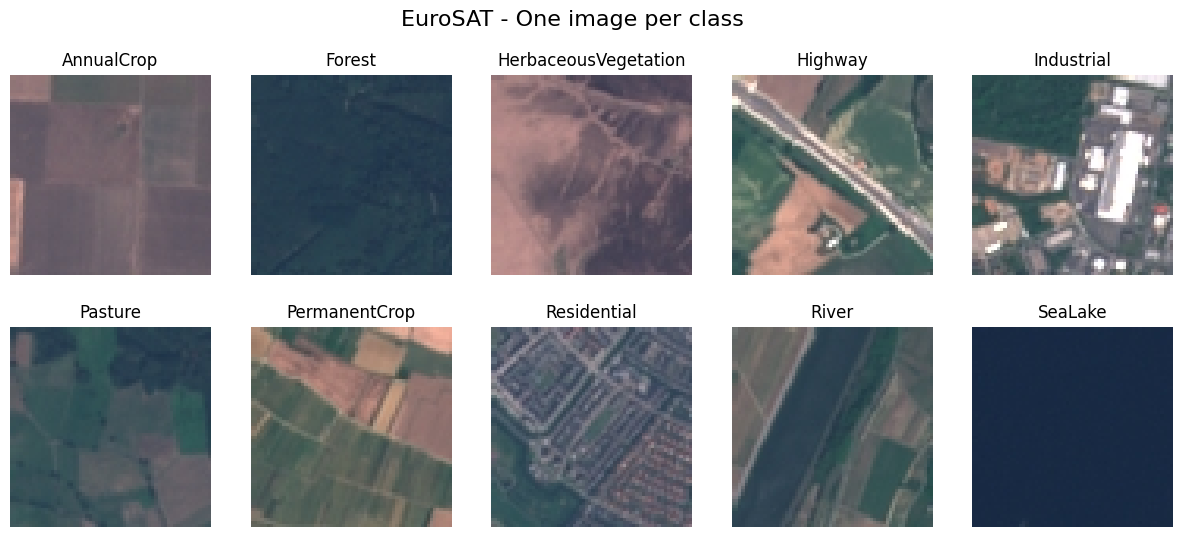

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for cls in range(num_classes):
    for img, label in eurosat_data:
        if label == cls:
            axes[cls].imshow(img.permute(1, 2, 0))
            axes[cls].set_title(class_names[cls])
            axes[cls].axis("off")
            break

plt.suptitle("EuroSAT - One image per class", fontsize=16)
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


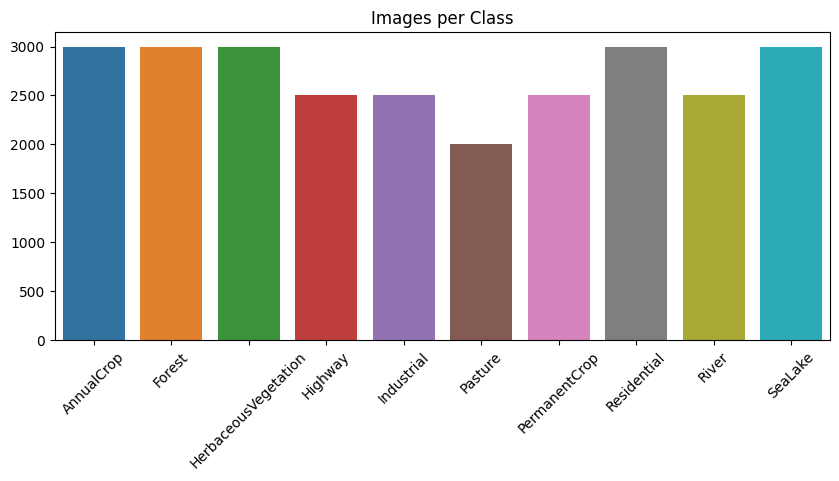

In [10]:
counts = [len(class_indices[c]) for c in range(num_classes)]
plt.figure(figsize=(10, 4))
sns.barplot(x=class_names, y=counts)
plt.xticks(rotation=45)
plt.title("Images per Class")
plt.show()

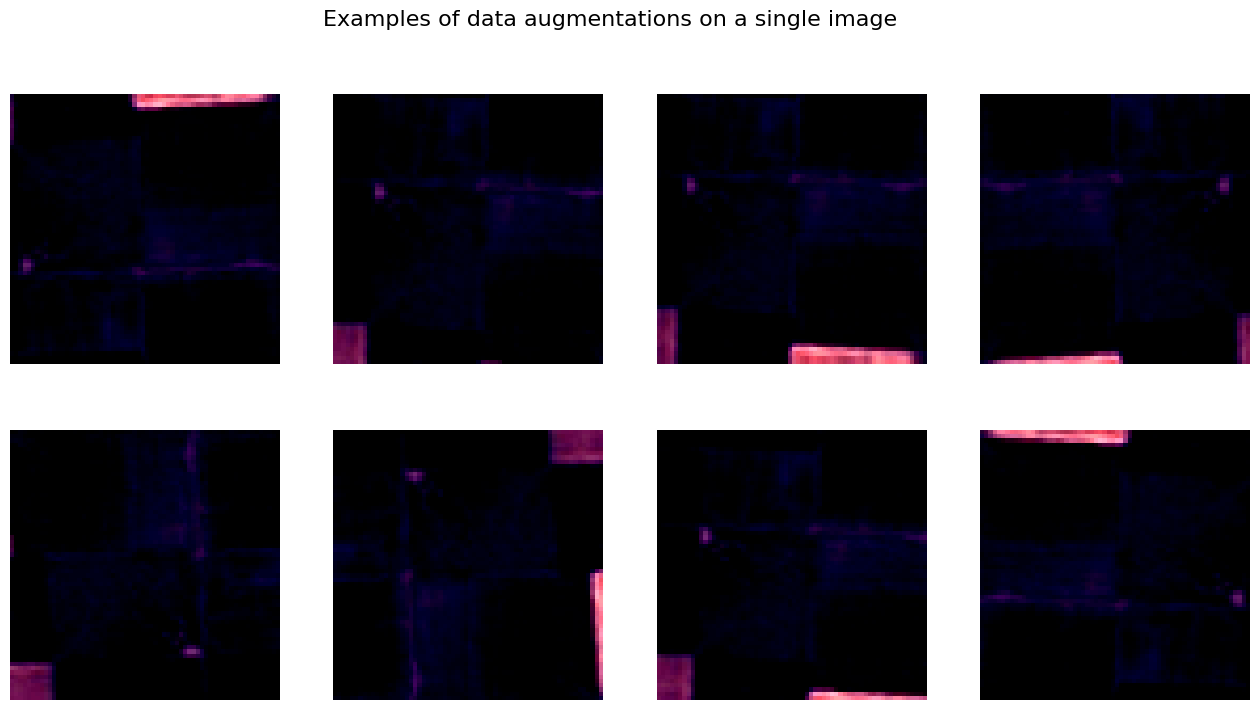

In [11]:
img, _ = eurosat_data[0]
pil_img = transforms.ToPILImage()(img)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    aug_img = train_transform(pil_img)
    axes[i].imshow(aug_img.permute(1, 2, 0).clamp(0, 1))
    axes[i].axis("off")

plt.suptitle("Examples of data augmentations on a single image", fontsize=16)
plt.show()

## 1: Baseline and Transfer Learning


### Task 1.1 - Baseline CNN from scratch


In [12]:
def train_per_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())

    acc = correct / total
    loss = total_loss / total
    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    cm = confusion_matrix(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")

    return loss, acc, cm, f1


def train_model(
    model,
    train_loader,
    val_loader,
    test_loader,
    optimizer,
    criterion,
    num_epochs,
    patience=3,
):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_no_improve = 0

    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_per_epoch(
            model, train_loader, optimizer, criterion
        )
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            best_epoch = epoch + 1
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(
                f"Early stopping triggered at epoch {epoch+1} "
                f"(best val loss: {best_val_loss:.4f})"
            )
            break

    model.load_state_dict(best_state)
    training_time = time.time() - start_time
    test_loss, test_acc, test_cm, test_f1 = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc * 100:.2f}%")
    print(f"Training Time: {training_time / 60:.2f} minutes")

    return {
        "best_epoch": best_epoch,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "confusion_matrix": test_cm,
        "training_time": training_time,
    }


def plot_train_curves(results, title=""):
    best_epoch = results["best_epoch"]
    epochs = range(1, len(results["train_losses"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, results["train_losses"], label="Train Loss")
    plt.plot(epochs, results["val_losses"], label="Val Loss")
    plt.axvline(best_epoch, linestyle="--", color="gray", label="Best Epoch")
    plt.legend()
    plt.title(f"Loss Curves - {title}")

    plt.subplot(1, 2, 2)
    plt.plot(epochs, results["train_accs"], label="Train Acc")
    plt.plot(epochs, results["val_accs"], label="Val Acc")
    plt.axvline(best_epoch, linestyle="--", color="gray", label="Best Epoch")
    plt.legend()
    plt.title(f"Accuracy Curves - {title}")

    plt.show()


def plot_confusion_matrix(cm, class_names, title=""):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names,
    )
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap="Blues", values_format="d", ax=ax, xticks_rotation="vertical")
    plt.title(f"Confusion Matrix - {title}")
    plt.show()

In [15]:
batch_size = 32

train_loader = DataLoader(
    train_full, batch_size=batch_size, shuffle=True, num_workers=2
)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)

In [16]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN(num_classes).to(device)
summary(model, input_size=(1, 3, 64, 64), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 10]                   --
├─Sequential: 1-1                        [1, 128, 8, 8]            --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           896
│    └─BatchNorm2d: 2-2                  [1, 32, 64, 64]           64
│    └─ReLU: 2-3                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-4                    [1, 32, 32, 32]           --
│    └─Conv2d: 2-5                       [1, 64, 32, 32]           18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 32, 32]           128
│    └─ReLU: 2-7                         [1, 64, 32, 32]           --
│    └─MaxPool2d: 2-8                    [1, 64, 16, 16]           --
│    └─Conv2d: 2-9                       [1, 128, 16, 16]          73,856
│    └─BatchNorm2d: 2-10                 [1, 128, 16, 16]          256
│    └─ReLU: 2-11                        [1, 128, 16, 16]          --
│   

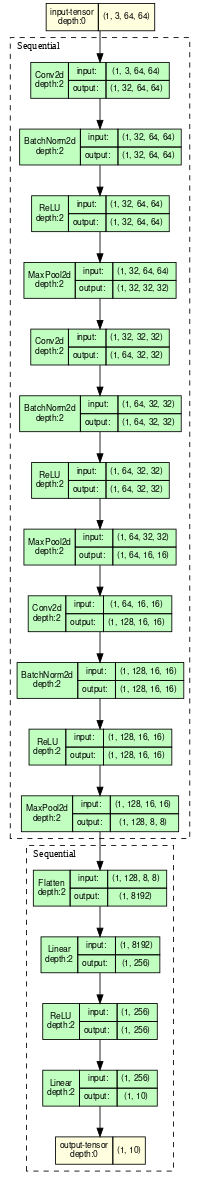

In [17]:
model_graph = draw_graph(
    model, input_size=(1, 3, 64, 64), expand_nested=True, device=device
)
model_graph.visual_graph.render("baseline_cnn", format="png")
display(Image("baseline_cnn.png"))

In [18]:
reproducibility()
cnn = CNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr=1e-3)

results_cnn = train_model(
    model=cnn,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=12,
)

Random seed set to 42
Epoch 1/12 | Train Loss: 1.0011, Train Acc: 0.6466 | Val Loss: 0.6932, Val Acc: 0.7558
Epoch 2/12 | Train Loss: 0.6903, Train Acc: 0.7545 | Val Loss: 0.5766, Val Acc: 0.7990
Epoch 3/12 | Train Loss: 0.5834, Train Acc: 0.7951 | Val Loss: 0.6986, Val Acc: 0.7879
Epoch 4/12 | Train Loss: 0.5140, Train Acc: 0.8188 | Val Loss: 0.4460, Val Acc: 0.8435
Epoch 5/12 | Train Loss: 0.4759, Train Acc: 0.8370 | Val Loss: 0.4616, Val Acc: 0.8375
Epoch 6/12 | Train Loss: 0.4344, Train Acc: 0.8495 | Val Loss: 0.3842, Val Acc: 0.8632
Epoch 7/12 | Train Loss: 0.3865, Train Acc: 0.8662 | Val Loss: 0.4016, Val Acc: 0.8647
Epoch 8/12 | Train Loss: 0.3616, Train Acc: 0.8725 | Val Loss: 0.4892, Val Acc: 0.8430
Epoch 9/12 | Train Loss: 0.3412, Train Acc: 0.8814 | Val Loss: 0.3242, Val Acc: 0.8832
Epoch 10/12 | Train Loss: 0.3166, Train Acc: 0.8917 | Val Loss: 0.2869, Val Acc: 0.9002
Epoch 11/12 | Train Loss: 0.2968, Train Acc: 0.8937 | Val Loss: 0.2774, Val Acc: 0.9044
Epoch 12/12 | Train

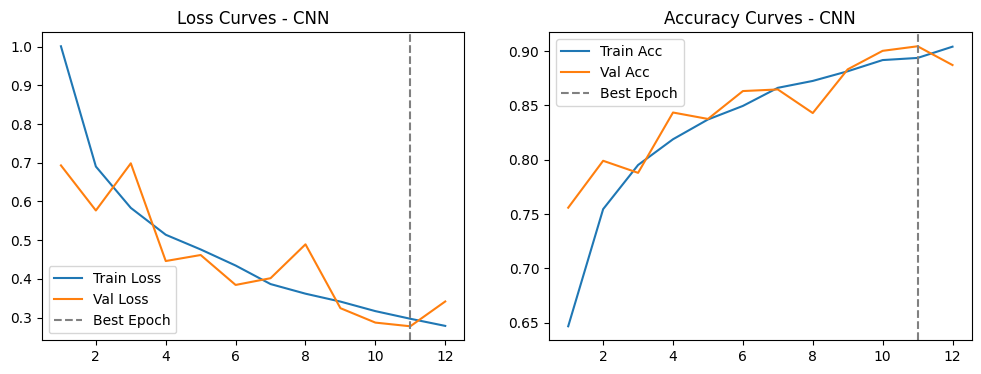

In [19]:
plot_train_curves(results_cnn, "CNN")

### Task 1.2 - Transfer Learning


In [20]:
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)
resnet50 = resnet50.to(device)
summary(resnet50, input_size=(1, 3, 64, 64), device=device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 167MB/s] 


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 32, 32]           9,408
├─BatchNorm2d: 1-2                       [1, 64, 32, 32]           128
├─ReLU: 1-3                              [1, 64, 32, 32]           --
├─MaxPool2d: 1-4                         [1, 64, 16, 16]           --
├─Sequential: 1-5                        [1, 256, 16, 16]          --
│    └─Bottleneck: 2-1                   [1, 256, 16, 16]          --
│    │    └─Conv2d: 3-1                  [1, 64, 16, 16]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 16, 16]           128
│    │    └─ReLU: 3-3                    [1, 64, 16, 16]           --
│    │    └─Conv2d: 3-4                  [1, 64, 16, 16]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 16, 16]           128
│    │    └─ReLU: 3-6                    [1, 64, 16, 16]           --
│ 

In [21]:
reproducibility()

resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)
resnet50 = resnet50.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(resnet50.parameters(), 1e-3)

results_resnet50 = train_model(
    model=resnet50,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42
Epoch 1/15 | Train Loss: 0.4556, Train Acc: 0.8615 | Val Loss: 0.2520, Val Acc: 0.9190
Epoch 2/15 | Train Loss: 0.2741, Train Acc: 0.9128 | Val Loss: 0.3661, Val Acc: 0.9000
Epoch 3/15 | Train Loss: 0.2390, Train Acc: 0.9223 | Val Loss: 0.1728, Val Acc: 0.9422
Epoch 4/15 | Train Loss: 0.2081, Train Acc: 0.9332 | Val Loss: 0.1916, Val Acc: 0.9400
Epoch 5/15 | Train Loss: 0.1934, Train Acc: 0.9358 | Val Loss: 0.1737, Val Acc: 0.9442
Epoch 6/15 | Train Loss: 0.1896, Train Acc: 0.9357 | Val Loss: 0.1443, Val Acc: 0.9538
Epoch 7/15 | Train Loss: 0.1707, Train Acc: 0.9440 | Val Loss: 0.2531, Val Acc: 0.9207
Epoch 8/15 | Train Loss: 0.1580, Train Acc: 0.9474 | Val Loss: 0.1458, Val Acc: 0.9526
Epoch 9/15 | Train Loss: 0.1543, Train Acc: 0.9503 | Val Loss: 0.1307, Val Acc: 0.9585
Epoch 10/15 | Train Loss: 0.1482, Train Acc: 0.9498 | Val Loss: 0.1190, Val Acc: 0.9654
Epoch 11/15 | Train Loss: 0.1416, Train Acc: 0.9521 | Val Loss: 0.1532, Val Acc: 0.9531
Epoch 12/15 | Train

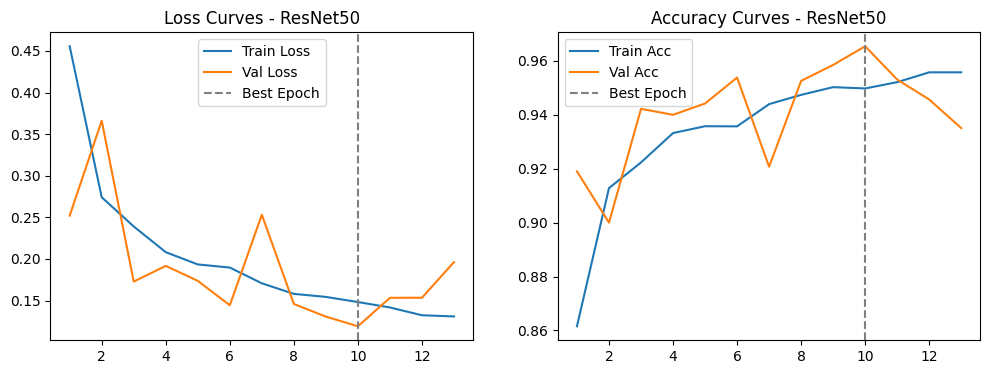

In [22]:
plot_train_curves(results_resnet50, "ResNet50")

In [23]:
resnet50_frozen = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for param in resnet50_frozen.parameters():
    param.requires_grad = False
resnet50_frozen.fc = nn.Linear(resnet50_frozen.fc.in_features, num_classes)
resnet50_frozen = resnet50_frozen.to(device)
summary(resnet50_frozen, input_size=(1, 3, 64, 64), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 32, 32]           (9,408)
├─BatchNorm2d: 1-2                       [1, 64, 32, 32]           (128)
├─ReLU: 1-3                              [1, 64, 32, 32]           --
├─MaxPool2d: 1-4                         [1, 64, 16, 16]           --
├─Sequential: 1-5                        [1, 256, 16, 16]          --
│    └─Bottleneck: 2-1                   [1, 256, 16, 16]          --
│    │    └─Conv2d: 3-1                  [1, 64, 16, 16]           (4,096)
│    │    └─BatchNorm2d: 3-2             [1, 64, 16, 16]           (128)
│    │    └─ReLU: 3-3                    [1, 64, 16, 16]           --
│    │    └─Conv2d: 3-4                  [1, 64, 16, 16]           (36,864)
│    │    └─BatchNorm2d: 3-5             [1, 64, 16, 16]           (128)
│    │    └─ReLU: 3-6                    [1, 64, 16, 16]    

In [24]:
reproducibility()

resnet50_frozen = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for param in resnet50_frozen.parameters():
    param.requires_grad = False
resnet50_frozen.fc = nn.Linear(resnet50_frozen.fc.in_features, num_classes)
resnet50_frozen = resnet50_frozen.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(resnet50_frozen.parameters(), 1e-3)

results_resnet50_frozen = train_model(
    model=resnet50_frozen,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=12,
)

Random seed set to 42
Epoch 1/12 | Train Loss: 0.8712, Train Acc: 0.7586 | Val Loss: 0.4905, Val Acc: 0.8538
Epoch 2/12 | Train Loss: 0.5695, Train Acc: 0.8269 | Val Loss: 0.4277, Val Acc: 0.8649
Epoch 3/12 | Train Loss: 0.5231, Train Acc: 0.8369 | Val Loss: 0.4049, Val Acc: 0.8681
Epoch 4/12 | Train Loss: 0.5048, Train Acc: 0.8367 | Val Loss: 0.4056, Val Acc: 0.8694
Epoch 5/12 | Train Loss: 0.4841, Train Acc: 0.8425 | Val Loss: 0.3789, Val Acc: 0.8741
Epoch 6/12 | Train Loss: 0.4863, Train Acc: 0.8414 | Val Loss: 0.3747, Val Acc: 0.8753
Epoch 7/12 | Train Loss: 0.4593, Train Acc: 0.8525 | Val Loss: 0.3808, Val Acc: 0.8802
Epoch 8/12 | Train Loss: 0.4718, Train Acc: 0.8478 | Val Loss: 0.3848, Val Acc: 0.8770
Epoch 9/12 | Train Loss: 0.4666, Train Acc: 0.8512 | Val Loss: 0.3946, Val Acc: 0.8768
Early stopping triggered at epoch 9 (best val loss: 0.3747)
Test Accuracy: 86.86%
Training Time: 2.10 minutes


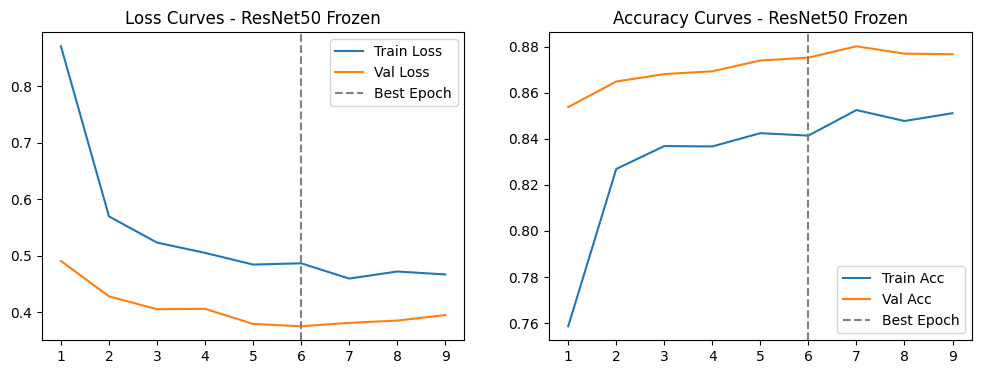

In [25]:
plot_train_curves(results_resnet50_frozen, "ResNet50 Frozen")

In [26]:
efficientnetb0 = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
in_features = efficientnetb0.classifier[1].in_features
efficientnetb0.classifier[1] = nn.Linear(in_features, num_classes)
efficientnetb0 = efficientnetb0.to(device)
summary(efficientnetb0, input_size=(1, 3, 64, 64), device=device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 151MB/s]


Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 10]                   --
├─Sequential: 1-1                                       [1, 1280, 2, 2]           --
│    └─Conv2dNormActivation: 2-1                        [1, 32, 32, 32]           --
│    │    └─Conv2d: 3-1                                 [1, 32, 32, 32]           864
│    │    └─BatchNorm2d: 3-2                            [1, 32, 32, 32]           64
│    │    └─SiLU: 3-3                                   [1, 32, 32, 32]           --
│    └─Sequential: 2-2                                  [1, 16, 32, 32]           --
│    │    └─MBConv: 3-4                                 [1, 16, 32, 32]           1,448
│    └─Sequential: 2-3                                  [1, 24, 16, 16]           --
│    │    └─MBConv: 3-5                                 [1, 24, 16, 16]           6,004
│    │    └─MBConv: 3-6                              

In [27]:
reproducibility()

efficientnetb0 = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
in_features = efficientnetb0.classifier[1].in_features
efficientnetb0.classifier[1] = nn.Linear(in_features, num_classes)
efficientnetb0 = efficientnetb0.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(efficientnetb0.parameters(), 1e-3)

results_efficientnetb0 = train_model(
    model=efficientnetb0,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42
Epoch 1/15 | Train Loss: 0.4629, Train Acc: 0.8614 | Val Loss: 0.2121, Val Acc: 0.9351
Epoch 2/15 | Train Loss: 0.2394, Train Acc: 0.9239 | Val Loss: 0.1289, Val Acc: 0.9553
Epoch 3/15 | Train Loss: 0.1821, Train Acc: 0.9414 | Val Loss: 0.2211, Val Acc: 0.9210
Epoch 4/15 | Train Loss: 0.1620, Train Acc: 0.9485 | Val Loss: 0.1242, Val Acc: 0.9630
Epoch 5/15 | Train Loss: 0.1468, Train Acc: 0.9514 | Val Loss: 0.0867, Val Acc: 0.9723
Epoch 6/15 | Train Loss: 0.1397, Train Acc: 0.9548 | Val Loss: 0.1197, Val Acc: 0.9622
Epoch 7/15 | Train Loss: 0.1323, Train Acc: 0.9573 | Val Loss: 0.1005, Val Acc: 0.9686
Epoch 8/15 | Train Loss: 0.1308, Train Acc: 0.9570 | Val Loss: 0.1026, Val Acc: 0.9686
Early stopping triggered at epoch 8 (best val loss: 0.0867)
Test Accuracy: 96.37%
Training Time: 3.16 minutes


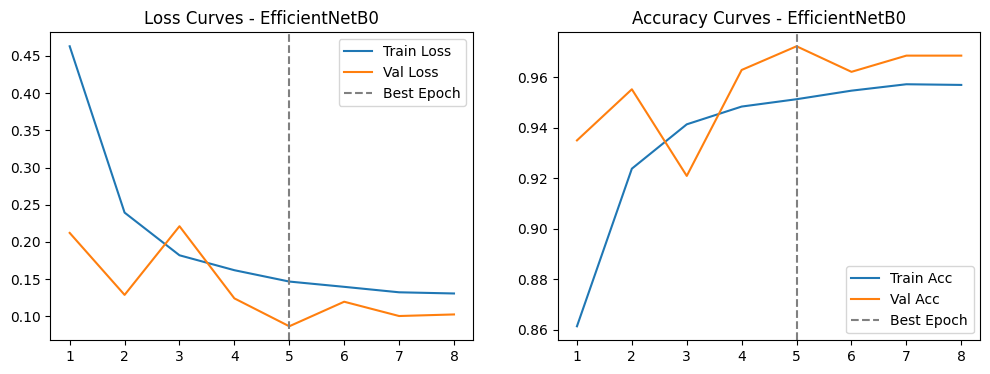

In [28]:
plot_train_curves(results_efficientnetb0, "EfficientNetB0")

In [29]:
efficientnetb0_frozen = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
for param in efficientnetb0_frozen.parameters():
    param.requires_grad = False
in_features = efficientnetb0_frozen.classifier[1].in_features
efficientnetb0_frozen.classifier[1] = nn.Linear(in_features, num_classes)
efficientnetb0_frozen = efficientnetb0_frozen.to(device)
summary(efficientnetb0_frozen, input_size=(1, 3, 64, 64), device=device)

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 10]                   --
├─Sequential: 1-1                                       [1, 1280, 2, 2]           --
│    └─Conv2dNormActivation: 2-1                        [1, 32, 32, 32]           --
│    │    └─Conv2d: 3-1                                 [1, 32, 32, 32]           (864)
│    │    └─BatchNorm2d: 3-2                            [1, 32, 32, 32]           (64)
│    │    └─SiLU: 3-3                                   [1, 32, 32, 32]           --
│    └─Sequential: 2-2                                  [1, 16, 32, 32]           --
│    │    └─MBConv: 3-4                                 [1, 16, 32, 32]           (1,448)
│    └─Sequential: 2-3                                  [1, 24, 16, 16]           --
│    │    └─MBConv: 3-5                                 [1, 24, 16, 16]           (6,004)
│    │    └─MBConv: 3-6                      

In [30]:
reproducibility()

efficientnetb0_frozen = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
for param in efficientnetb0_frozen.parameters():
    param.requires_grad = False
in_features = efficientnetb0_frozen.classifier[1].in_features
efficientnetb0_frozen.classifier[1] = nn.Linear(in_features, num_classes)
efficientnetb0_frozen = efficientnetb0_frozen.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(efficientnetb0_frozen.parameters(), 1e-3)

results_efficientnetb0_frozen = train_model(
    model=efficientnetb0_frozen,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42
Epoch 1/15 | Train Loss: 0.8824, Train Acc: 0.7184 | Val Loss: 0.8649, Val Acc: 0.7620
Epoch 2/15 | Train Loss: 0.7259, Train Acc: 0.7575 | Val Loss: 0.7706, Val Acc: 0.7751
Epoch 3/15 | Train Loss: 0.7173, Train Acc: 0.7596 | Val Loss: 0.6816, Val Acc: 0.7689
Epoch 4/15 | Train Loss: 0.7231, Train Acc: 0.7598 | Val Loss: 0.6669, Val Acc: 0.7746
Epoch 5/15 | Train Loss: 0.7086, Train Acc: 0.7625 | Val Loss: 0.6943, Val Acc: 0.7862
Epoch 6/15 | Train Loss: 0.7055, Train Acc: 0.7644 | Val Loss: 0.6677, Val Acc: 0.7815
Epoch 7/15 | Train Loss: 0.7119, Train Acc: 0.7616 | Val Loss: 0.7187, Val Acc: 0.7709
Early stopping triggered at epoch 7 (best val loss: 0.6669)
Test Accuracy: 76.79%
Training Time: 1.73 minutes


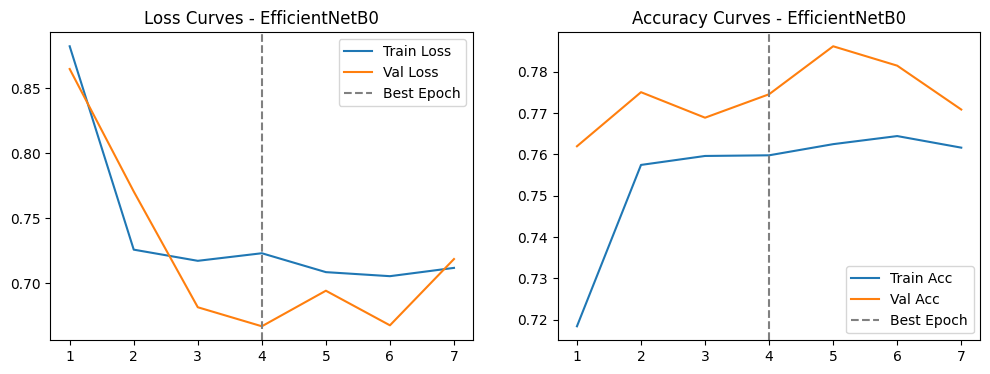

In [31]:
plot_train_curves(results_efficientnetb0_frozen, "EfficientNetB0")

In [ ]:
train_transform_vit = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomChoice(
            [
                transforms.RandomRotation((0, 0)),
                transforms.RandomRotation((90, 90)),
                transforms.RandomRotation((180, 180)),
                transforms.RandomRotation((270, 270)),
            ]
        ),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

val_test_transform_vit = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_full_vit = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform_vit),
    train_full_idx,
)
val_set_vit = Subset(
    datasets.EuroSAT(root="./data", transform=val_test_transform_vit),
    val_idx,
)
test_set_vit = Subset(
    datasets.EuroSAT(root="./data", transform=val_test_transform_vit),
    test_idx,
)

batch_size_vit = 32

train_loader_vit = DataLoader(
    train_full_vit, batch_size=batch_size_vit, shuffle=True, num_workers=2
)
val_loader_vit = DataLoader(
    val_set_vit, batch_size=batch_size_vit, shuffle=False, num_workers=2
)
test_loader_vit = DataLoader(
    test_set_vit, batch_size=batch_size_vit, shuffle=False, num_workers=2
)

In [38]:
vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
in_features = vit.heads.head.in_features
vit.heads.head = nn.Linear(in_features, num_classes)
vit = vit.to(device)
summary(vit, input_size=(1, 3, 224, 224), device=device)

Layer (type:depth-idx)                        Output Shape              Param #
VisionTransformer                             [1, 10]                   768
├─Conv2d: 1-1                                 [1, 768, 14, 14]          590,592
├─Encoder: 1-2                                [1, 197, 768]             151,296
│    └─Dropout: 2-1                           [1, 197, 768]             --
│    └─Sequential: 2-2                        [1, 197, 768]             --
│    │    └─EncoderBlock: 3-1                 [1, 197, 768]             7,087,872
│    │    └─EncoderBlock: 3-2                 [1, 197, 768]             7,087,872
│    │    └─EncoderBlock: 3-3                 [1, 197, 768]             7,087,872
│    │    └─EncoderBlock: 3-4                 [1, 197, 768]             7,087,872
│    │    └─EncoderBlock: 3-5                 [1, 197, 768]             7,087,872
│    │    └─EncoderBlock: 3-6                 [1, 197, 768]             7,087,872
│    │    └─EncoderBlock: 3-7             

In [39]:
reproducibility()

vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
in_features = vit.heads.head.in_features
vit.heads.head = nn.Linear(in_features, num_classes)
vit = vit.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(vit.parameters(), 1e-4)

results_vit = train_model(
    model=vit,
    train_loader=train_loader_vit,
    val_loader=val_loader_vit,
    test_loader=test_loader_vit,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=10,
)

Random seed set to 42
Epoch 1/10 | Train Loss: 0.2086, Train Acc: 0.9319 | Val Loss: 0.1237, Val Acc: 0.9625
Epoch 2/10 | Train Loss: 0.1082, Train Acc: 0.9646 | Val Loss: 0.0839, Val Acc: 0.9758
Epoch 3/10 | Train Loss: 0.1000, Train Acc: 0.9663 | Val Loss: 0.0857, Val Acc: 0.9696
Epoch 4/10 | Train Loss: 0.0755, Train Acc: 0.9744 | Val Loss: 0.1121, Val Acc: 0.9612
Epoch 5/10 | Train Loss: 0.0768, Train Acc: 0.9743 | Val Loss: 0.0957, Val Acc: 0.9672
Early stopping triggered at epoch 5 (best val loss: 0.0839)
Test Accuracy: 97.31%
Training Time: 63.27 minutes


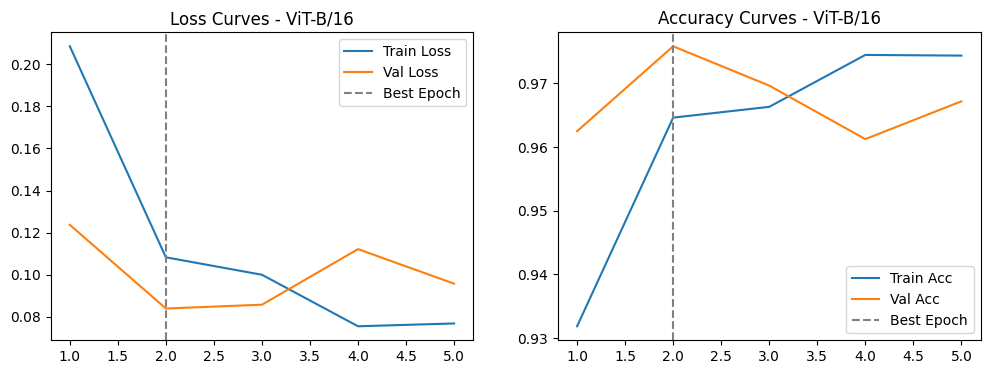

In [40]:
plot_train_curves(results_vit, "ViT-B/16")

In [41]:
vit_frozen = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
in_features = vit_frozen.heads.head.in_features
vit_frozen.heads.head = nn.Linear(in_features, num_classes)
for param in vit_frozen.parameters():
    param.requires_grad = False
for param in vit_frozen.heads.parameters():
    param.requires_grad = True
vit_frozen = vit_frozen.to(device)
summary(vit_frozen, input_size=(1, 3, 224, 224), device=device)

Layer (type:depth-idx)                        Output Shape              Param #
VisionTransformer                             [1, 10]                   768
├─Conv2d: 1-1                                 [1, 768, 14, 14]          (590,592)
├─Encoder: 1-2                                [1, 197, 768]             151,296
│    └─Dropout: 2-1                           [1, 197, 768]             --
│    └─Sequential: 2-2                        [1, 197, 768]             --
│    │    └─EncoderBlock: 3-1                 [1, 197, 768]             (7,087,872)
│    │    └─EncoderBlock: 3-2                 [1, 197, 768]             (7,087,872)
│    │    └─EncoderBlock: 3-3                 [1, 197, 768]             (7,087,872)
│    │    └─EncoderBlock: 3-4                 [1, 197, 768]             (7,087,872)
│    │    └─EncoderBlock: 3-5                 [1, 197, 768]             (7,087,872)
│    │    └─EncoderBlock: 3-6                 [1, 197, 768]             (7,087,872)
│    │    └─EncoderBlock: 3-

In [42]:
reproducibility()

vit_frozen = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
in_features = vit_frozen.heads.head.in_features
vit_frozen.heads.head = nn.Linear(in_features, num_classes)
for param in vit_frozen.parameters():
    param.requires_grad = False
for param in vit_frozen.heads.parameters():
    param.requires_grad = True
vit_frozen = vit_frozen.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(vit_frozen.parameters(), 1e-3)

results_vit_frozen = train_model(
    model=vit_frozen,
    train_loader=train_loader_vit,
    val_loader=val_loader_vit,
    test_loader=test_loader_vit,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42
Epoch 1/15 | Train Loss: 0.3233, Train Acc: 0.9103 | Val Loss: 0.1904, Val Acc: 0.9395
Epoch 2/15 | Train Loss: 0.1459, Train Acc: 0.9553 | Val Loss: 0.1310, Val Acc: 0.9612
Epoch 3/15 | Train Loss: 0.1145, Train Acc: 0.9640 | Val Loss: 0.1129, Val Acc: 0.9622
Epoch 4/15 | Train Loss: 0.1043, Train Acc: 0.9664 | Val Loss: 0.1103, Val Acc: 0.9622
Epoch 5/15 | Train Loss: 0.0945, Train Acc: 0.9705 | Val Loss: 0.1038, Val Acc: 0.9657
Epoch 6/15 | Train Loss: 0.0879, Train Acc: 0.9700 | Val Loss: 0.1016, Val Acc: 0.9669
Epoch 7/15 | Train Loss: 0.0830, Train Acc: 0.9724 | Val Loss: 0.1036, Val Acc: 0.9664
Epoch 8/15 | Train Loss: 0.0758, Train Acc: 0.9750 | Val Loss: 0.1078, Val Acc: 0.9654
Epoch 9/15 | Train Loss: 0.0733, Train Acc: 0.9761 | Val Loss: 0.0927, Val Acc: 0.9684
Epoch 10/15 | Train Loss: 0.0710, Train Acc: 0.9772 | Val Loss: 0.0983, Val Acc: 0.9664
Epoch 11/15 | Train Loss: 0.0677, Train Acc: 0.9771 | Val Loss: 0.0932, Val Acc: 0.9696
Epoch 12/15 | Train

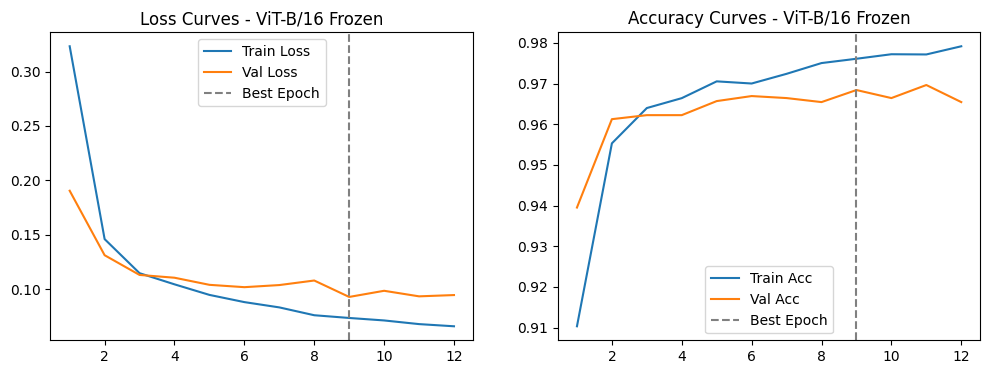

In [43]:
plot_train_curves(results_vit_frozen, "ViT-B/16 Frozen")

### Task 1.3 – Transfer Learning in Few-Shot scenarios


In [ ]:
batch_size = 32

train_10shot_loader = DataLoader(
    train_10shot, batch_size=batch_size, shuffle=True, num_workers=2
)

train_5shot_loader = DataLoader(
    train_5shot, batch_size=batch_size, shuffle=True, num_workers=2
)

In [44]:
batch_size_vit = 32

train_10shot_vit = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform_vit),
    train_10shot_idx,
)

train_loader_vit_10shot = DataLoader(
    train_10shot_vit, batch_size=batch_size_vit, shuffle=True, num_workers=2
)

train_5shot_vit = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform_vit),
    train_5shot_idx,
)

train_loader_vit_5shot = DataLoader(
    train_5shot_vit, batch_size=batch_size_vit, shuffle=True, num_workers=2
)

In [45]:
reproducibility()

vit_10shot = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
in_features = vit_10shot.heads.head.in_features
vit_10shot.heads.head = nn.Linear(in_features, num_classes)
vit_10shot = vit_10shot.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(vit_10shot.parameters(), 1e-4)

results_vit_10shot = train_model(
    model=vit_10shot,
    train_loader=train_loader_vit_10shot,
    val_loader=val_loader_vit,
    test_loader=test_loader_vit,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42
Epoch 1/15 | Train Loss: 2.1484, Train Acc: 0.2200 | Val Loss: 1.4765, Val Acc: 0.5388
Epoch 2/15 | Train Loss: 1.1521, Train Acc: 0.6000 | Val Loss: 0.8965, Val Acc: 0.7348
Epoch 3/15 | Train Loss: 0.6252, Train Acc: 0.8300 | Val Loss: 0.7189, Val Acc: 0.7795
Epoch 4/15 | Train Loss: 0.3146, Train Acc: 0.9700 | Val Loss: 0.5550, Val Acc: 0.8358
Epoch 5/15 | Train Loss: 0.2193, Train Acc: 0.9500 | Val Loss: 0.4820, Val Acc: 0.8440
Epoch 6/15 | Train Loss: 0.0986, Train Acc: 1.0000 | Val Loss: 0.4286, Val Acc: 0.8632
Epoch 7/15 | Train Loss: 0.0728, Train Acc: 1.0000 | Val Loss: 0.4789, Val Acc: 0.8444
Epoch 8/15 | Train Loss: 0.1319, Train Acc: 0.9700 | Val Loss: 0.5953, Val Acc: 0.8047
Epoch 9/15 | Train Loss: 0.0705, Train Acc: 0.9900 | Val Loss: 0.5486, Val Acc: 0.8348
Early stopping triggered at epoch 9 (best val loss: 0.4286)
Test Accuracy: 84.79%
Training Time: 8.01 minutes


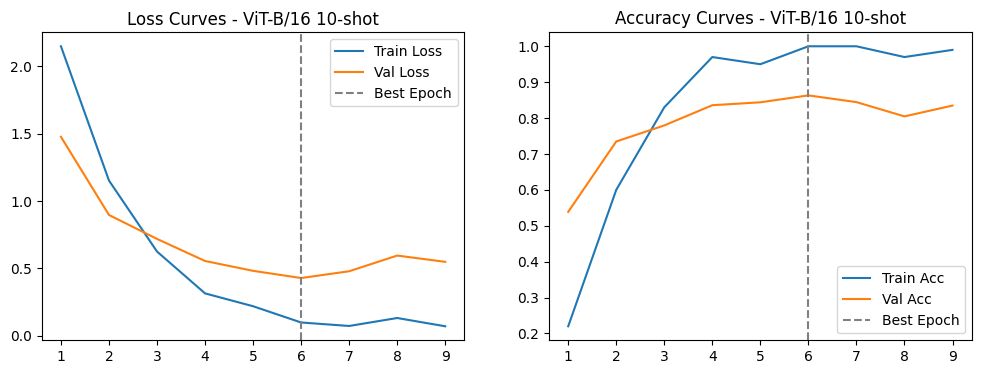

In [46]:
plot_train_curves(results_vit_10shot, "ViT-B/16 10-shot")

In [48]:
reproducibility()

vit_5shot = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
in_features = vit_5shot.heads.head.in_features
vit_5shot.heads.head = nn.Linear(in_features, num_classes)
vit_5shot = vit_5shot.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(vit_5shot.parameters(), 1e-4)

results_vit_5shot = train_model(
    model=vit_5shot,
    train_loader=train_loader_vit_5shot,
    val_loader=val_loader_vit,
    test_loader=test_loader_vit,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42
Epoch 1/15 | Train Loss: 2.4409, Train Acc: 0.0800 | Val Loss: 1.7653, Val Acc: 0.5077
Epoch 2/15 | Train Loss: 1.4121, Train Acc: 0.7200 | Val Loss: 1.2880, Val Acc: 0.6775
Epoch 3/15 | Train Loss: 0.7819, Train Acc: 0.9000 | Val Loss: 0.9960, Val Acc: 0.7316
Epoch 4/15 | Train Loss: 0.4193, Train Acc: 1.0000 | Val Loss: 0.7316, Val Acc: 0.7998
Epoch 5/15 | Train Loss: 0.2048, Train Acc: 1.0000 | Val Loss: 0.6452, Val Acc: 0.8126
Epoch 6/15 | Train Loss: 0.1348, Train Acc: 1.0000 | Val Loss: 0.5830, Val Acc: 0.8170
Epoch 7/15 | Train Loss: 0.0944, Train Acc: 1.0000 | Val Loss: 0.5683, Val Acc: 0.8180
Epoch 8/15 | Train Loss: 0.0614, Train Acc: 1.0000 | Val Loss: 0.5444, Val Acc: 0.8252
Epoch 9/15 | Train Loss: 0.0317, Train Acc: 1.0000 | Val Loss: 0.4871, Val Acc: 0.8499
Epoch 10/15 | Train Loss: 0.0232, Train Acc: 1.0000 | Val Loss: 0.4731, Val Acc: 0.8538
Epoch 11/15 | Train Loss: 0.0181, Train Acc: 1.0000 | Val Loss: 0.4635, Val Acc: 0.8511
Epoch 12/15 | Train

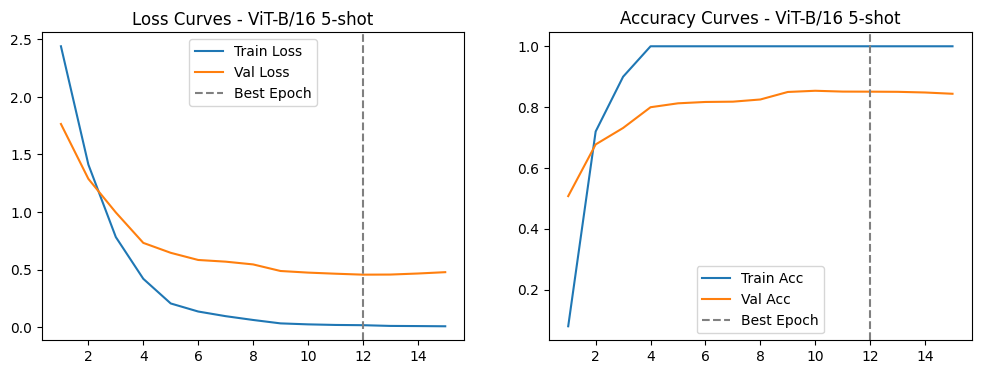

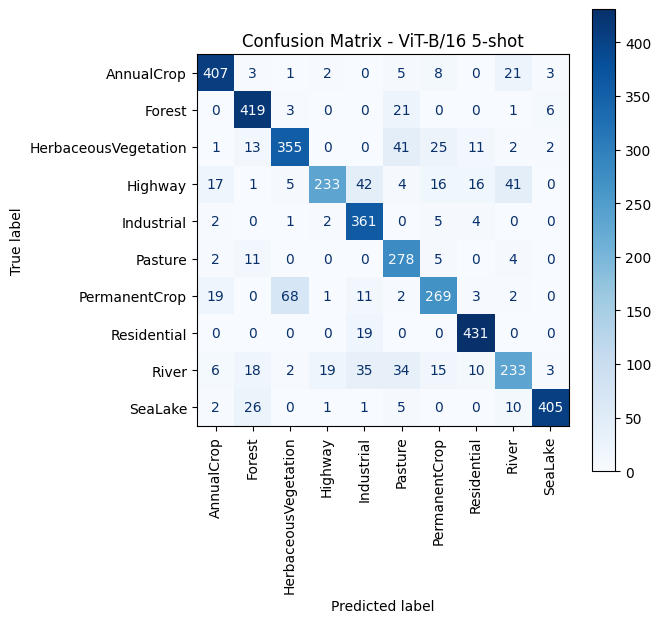

In [49]:
plot_train_curves(results_vit_5shot, "ViT-B/16 5-shot")
plot_confusion_matrix(
    results_vit_5shot["confusion_matrix"],
    class_names,
    "ViT-B/16 5-shot",
)

In [50]:
reproducibility()

vit_frozen_10shot = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
in_features = vit_frozen_10shot.heads.head.in_features
vit_frozen_10shot.heads.head = nn.Linear(in_features, num_classes)
for param in vit_frozen_10shot.parameters():
    param.requires_grad = False
for param in vit_frozen_10shot.heads.parameters():
    param.requires_grad = True
vit_frozen_10shot = vit_frozen_10shot.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(vit_frozen_10shot.parameters(), 1e-3)

results_vit_frozen_10shot = train_model(
    model=vit_frozen_10shot,
    train_loader=train_loader_vit_10shot,
    val_loader=val_loader_vit,
    test_loader=test_loader_vit,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42
Epoch 1/15 | Train Loss: 2.3310, Train Acc: 0.1200 | Val Loss: 2.0206, Val Acc: 0.3756
Epoch 2/15 | Train Loss: 1.8569, Train Acc: 0.4900 | Val Loss: 1.7254, Val Acc: 0.5612
Epoch 3/15 | Train Loss: 1.5445, Train Acc: 0.6500 | Val Loss: 1.5076, Val Acc: 0.6326
Epoch 4/15 | Train Loss: 1.2642, Train Acc: 0.7600 | Val Loss: 1.3333, Val Acc: 0.6746
Epoch 5/15 | Train Loss: 1.0602, Train Acc: 0.8100 | Val Loss: 1.1851, Val Acc: 0.7185
Epoch 6/15 | Train Loss: 0.9079, Train Acc: 0.8800 | Val Loss: 1.0655, Val Acc: 0.7543
Epoch 7/15 | Train Loss: 0.7783, Train Acc: 0.9100 | Val Loss: 0.9728, Val Acc: 0.7746
Epoch 8/15 | Train Loss: 0.6705, Train Acc: 0.9200 | Val Loss: 0.9134, Val Acc: 0.7738
Epoch 9/15 | Train Loss: 0.5849, Train Acc: 0.9500 | Val Loss: 0.8702, Val Acc: 0.7758
Epoch 10/15 | Train Loss: 0.5041, Train Acc: 0.9600 | Val Loss: 0.8258, Val Acc: 0.7849
Epoch 11/15 | Train Loss: 0.4741, Train Acc: 0.9700 | Val Loss: 0.7822, Val Acc: 0.7916
Epoch 12/15 | Train

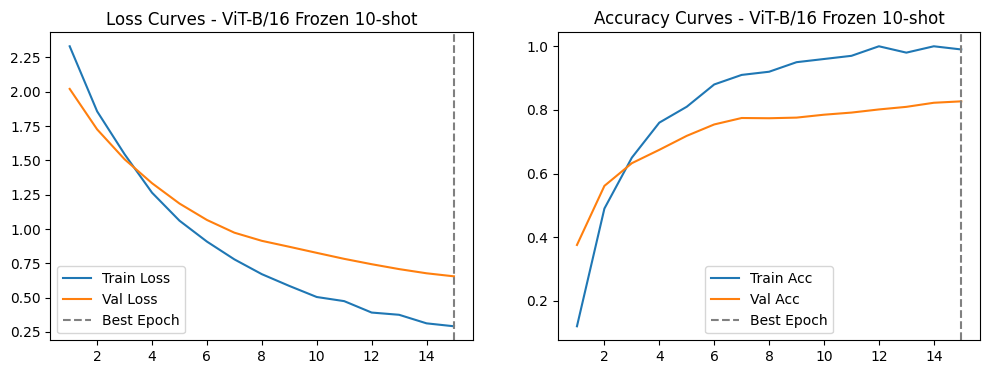

In [51]:
plot_train_curves(results_vit_frozen_10shot, "ViT-B/16 Frozen 10-shot")

In [52]:
reproducibility()

vit_frozen_5shot = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
in_features = vit_frozen_5shot.heads.head.in_features
vit_frozen_5shot.heads.head = nn.Linear(in_features, num_classes)
for param in vit_frozen_5shot.parameters():
    param.requires_grad = False
for param in vit_frozen_5shot.heads.parameters():
    param.requires_grad = True
vit_frozen_5shot = vit_frozen_5shot.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(vit_frozen_5shot.parameters(), 1e-3)

results_vit_frozen_5shot = train_model(
    model=vit_frozen_5shot,
    train_loader=train_loader_vit_5shot,
    val_loader=val_loader_vit,
    test_loader=test_loader_vit,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42
Epoch 1/15 | Train Loss: 2.3957, Train Acc: 0.1200 | Val Loss: 2.2066, Val Acc: 0.2067
Epoch 2/15 | Train Loss: 2.0669, Train Acc: 0.3800 | Val Loss: 2.0142, Val Acc: 0.3889
Epoch 3/15 | Train Loss: 1.7872, Train Acc: 0.6000 | Val Loss: 1.8429, Val Acc: 0.4993
Epoch 4/15 | Train Loss: 1.5392, Train Acc: 0.7400 | Val Loss: 1.6918, Val Acc: 0.5691
Epoch 5/15 | Train Loss: 1.3683, Train Acc: 0.8800 | Val Loss: 1.5601, Val Acc: 0.6170
Epoch 6/15 | Train Loss: 1.1817, Train Acc: 0.9400 | Val Loss: 1.4432, Val Acc: 0.6531
Epoch 7/15 | Train Loss: 0.9975, Train Acc: 0.9600 | Val Loss: 1.3429, Val Acc: 0.6743
Epoch 8/15 | Train Loss: 0.9197, Train Acc: 0.9600 | Val Loss: 1.2555, Val Acc: 0.6928
Epoch 9/15 | Train Loss: 0.7757, Train Acc: 0.9600 | Val Loss: 1.1815, Val Acc: 0.7072
Epoch 10/15 | Train Loss: 0.6728, Train Acc: 1.0000 | Val Loss: 1.1169, Val Acc: 0.7183
Epoch 11/15 | Train Loss: 0.6214, Train Acc: 1.0000 | Val Loss: 1.0611, Val Acc: 0.7281
Epoch 12/15 | Train

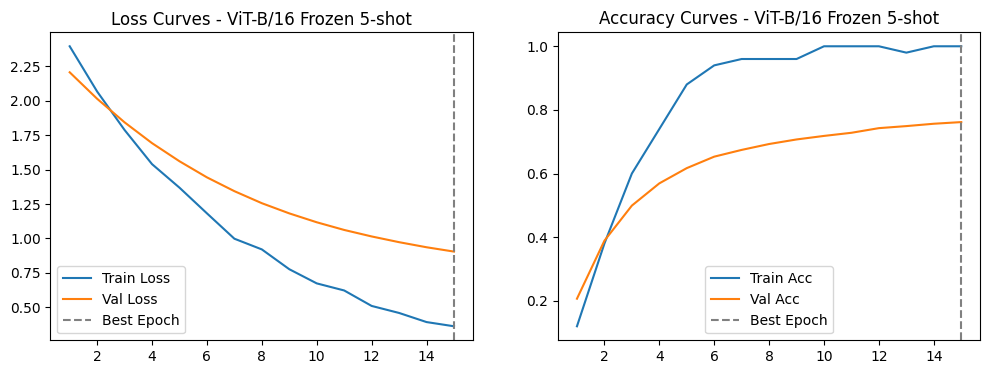

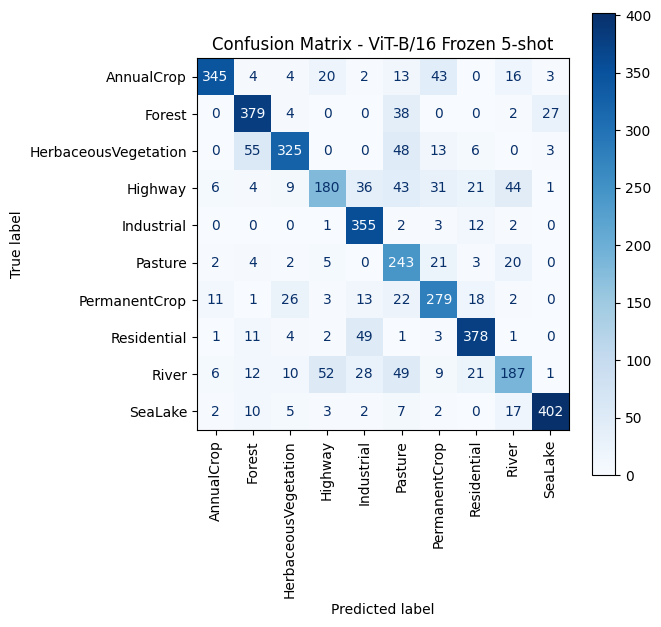

In [53]:
plot_train_curves(results_vit_frozen_5shot, "ViT-B/16 Frozen 5-shot")
plot_confusion_matrix(
    results_vit_frozen_5shot["confusion_matrix"],
    class_names,
    "ViT-B/16 Frozen 5-shot",
)

## 2 – Few-Shot and Zero-Shot Learning


### Task 2.1 – Prototype-based Few-Shot Classifier


In [14]:
def extract_embeddings(model, loader):
    embeddings = []
    labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            feats = model(x)
            embeddings.append(feats.cpu())
            labels.append(y)

    return torch.cat(embeddings), torch.cat(labels)


def compute_prototypes(embeddings, labels, num_classes):
    prototypes = []

    for i in range(num_classes):
        class_embeddings = embeddings[labels == i]
        prototype = class_embeddings.mean(dim=0)
        prototypes.append(prototype)

    return torch.stack(prototypes)


def prototype_classify(test_embeddings, prototypes, metric="euclidean"):
    if metric == "euclidean":
        dists = torch.cdist(test_embeddings, prototypes)
        preds = dists.argmin(dim=1)
    elif metric == "cosine":
        test_norm = F.normalize(test_embeddings, dim=1)
        proto_norm = F.normalize(prototypes, dim=1)
        sims = test_norm @ proto_norm.T
        preds = sims.argmax(dim=1)
    else:
        raise ValueError("Metric must be euclidean or cosine.")

    return preds


def evaluate_few_shot(loader, test_loader, encoder, num_classes, metric="euclidean"):
    embeddings, labels = extract_embeddings(encoder, loader)
    test_embeddings, test_labels = extract_embeddings(encoder, test_loader)
    prototypes = compute_prototypes(embeddings, labels, num_classes)
    preds = prototype_classify(test_embeddings, prototypes, metric)
    acc = (preds == test_labels).float().mean().item()

    return acc

In [49]:
reproducibility()

batch_size = 16

support_10shot_loader = DataLoader(
    train_10shot, batch_size=batch_size, shuffle=False, num_workers=2
)

support_5shot_loader = DataLoader(
    train_5shot, batch_size=batch_size, shuffle=False, num_workers=2
)

test_loader_proto = DataLoader(
    test_set, batch_size=batch_size, shuffle=False, num_workers=2
)

encoder = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
encoder.fc = nn.Identity()
for param in encoder.parameters():
    param.requires_grad = False
encoder = encoder.to(device)
encoder.eval()

acc_10shot_euc = evaluate_few_shot(
    support_10shot_loader,
    test_loader_proto,
    encoder,
    num_classes,
    metric="euclidean",
)

acc_10shot_cos = evaluate_few_shot(
    support_10shot_loader,
    test_loader_proto,
    encoder,
    num_classes,
    metric="cosine",
)

acc_5shot_euc = evaluate_few_shot(
    support_5shot_loader,
    test_loader_proto,
    encoder,
    num_classes,
    metric="euclidean",
)

acc_5shot_cos = evaluate_few_shot(
    support_5shot_loader,
    test_loader_proto,
    encoder,
    num_classes,
    metric="cosine",
)

print(f"10-shot Euclidean Accuracy: {acc_10shot_euc*100:.2f}%")
print(f"10-shot Cosine Accuracy: {acc_10shot_cos*100:.2f}%")

print(f"5-shot Euclidean Accuracy: {acc_5shot_euc*100:.2f}%")
print(f"5-shot Cosine Accuracy: {acc_5shot_cos*100:.2f}%")

Random seed set to 42
10-shot Euclidean Accuracy: 58.30%
10-shot Cosine Accuracy: 57.63%
5-shot Euclidean Accuracy: 38.05%
5-shot Cosine Accuracy: 44.59%


### Task 2.2 – Zero-Shot Learning with CLIP


In [34]:
def clip_collate_fn(batch):
    images, labels = zip(*batch)
    return list(images), torch.tensor(labels)


test_set_clip = Subset(
    datasets.EuroSAT(root="./data", transform=None),
    test_idx,
)

batch_size_clip = 32

test_loader_clip = DataLoader(
    test_set_clip,
    batch_size=batch_size_clip,
    shuffle=False,
    num_workers=2,
    collate_fn=clip_collate_fn,
)

In [35]:
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model = clip_model.to(device)
clip_model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [15]:
basic_prompt = ["a satellite image of {}"]
domain_prompts = [
    "an aerial view of {} terrain",
    "a satellite photograph showing {} land use",
    "top-down view of {} area",
]


def encode_text(prompts):
    text_inputs = clip_processor(text=prompts, padding=True, return_tensors="pt").to(
        device
    )

    with torch.no_grad():
        text_features = clip_model.get_text_features(**text_inputs)

    text_features = F.normalize(text_features, dim=1)
    return text_features


def build_zeroshot_classifier(prompt_templates, class_names):
    all_embeddings = []

    for template in prompt_templates:
        prompts = [template.format(c) for c in class_names]
        text_emb = encode_text(prompts)
        all_embeddings.append(text_emb)

    zeroshot_weights = torch.stack(all_embeddings).mean(dim=0)
    zeroshot_weights = F.normalize(zeroshot_weights, dim=-1)

    return zeroshot_weights


def clip_zeroshot_eval(dataloader, zeroshot_weights):
    correct = 0
    total = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            labels = labels.to(device)

            image_inputs = clip_processor(images=images, return_tensors="pt").to(device)
            image_inputs.to(device)

            image_features = clip_model.get_image_features(**image_inputs)
            image_features = F.normalize(image_features, dim=-1)

            logits = image_features @ zeroshot_weights.T
            preds = logits.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    acc = correct / total
    return acc, torch.cat(all_preds), torch.cat(all_labels)


def per_class_accuracy(y_true, y_pred, class_names):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accs = {}
    for i, c in enumerate(class_names):
        mask = y_true == i
        acc = (y_pred[mask] == i).mean() if mask.sum() > 0 else 0.0
        accs[c] = acc

    return accs

In [37]:
results_clip = {}

weights_basic = build_zeroshot_classifier(basic_prompt, class_names)
acc_basic, _, _ = clip_zeroshot_eval(test_loader_clip, weights_basic)
results_clip["Basic prompt"] = acc_basic

for i, p in enumerate(domain_prompts):
    weights = build_zeroshot_classifier([p], class_names)
    acc, _, _ = clip_zeroshot_eval(test_loader_clip, weights)
    results_clip[f"Domain prompt {i+1}"] = acc

weights_ensemble = build_zeroshot_classifier(basic_prompt + domain_prompts, class_names)
acc_ensemble, preds_clip, labels_clip = clip_zeroshot_eval(
    test_loader_clip, weights_ensemble
)
results_clip["Ensemble"] = acc_ensemble

for k, v in results_clip.items():
    print(f"{k:<20} : {v*100:.2f}%")

Basic prompt         : 39.60%
Domain prompt 1      : 32.57%
Domain prompt 2      : 42.57%
Domain prompt 3      : 32.64%
Ensemble             : 37.58%


CLIP Zero-Shot Per-Class Accuracy (Ensemble):

Residential            : 86.89%
Industrial             : 67.20%
Highway                : 63.20%
River                  : 52.53%
Forest                 : 44.00%
PermanentCrop          : 34.13%
AnnualCrop             : 15.11%
SeaLake                : 9.56%
Pasture                : 2.67%
HerbaceousVegetation   : 0.00%


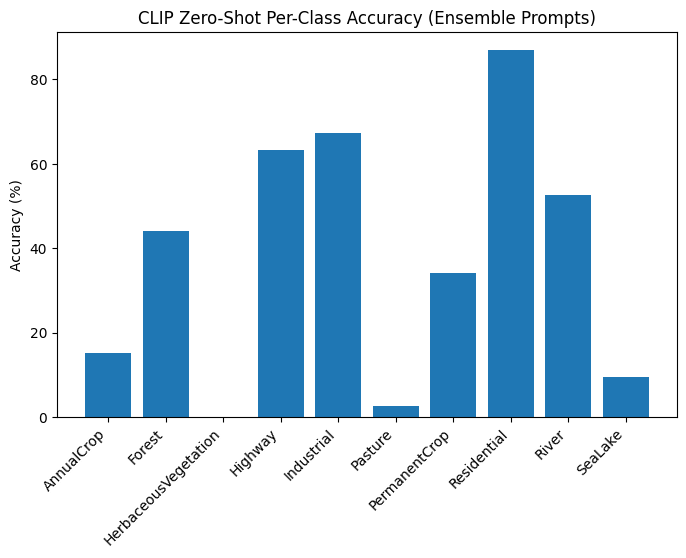

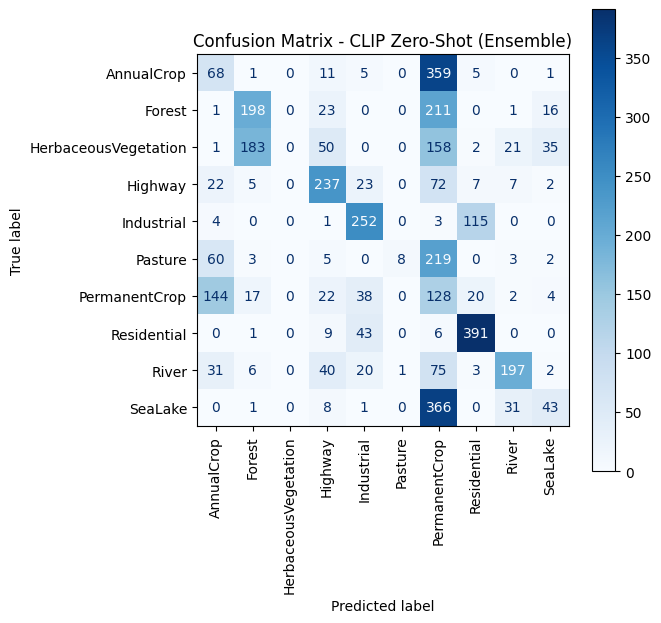

In [43]:
class_acc_clip = per_class_accuracy(
    labels_clip.numpy(), preds_clip.numpy(), class_names
)

print("CLIP Zero-Shot Per-Class Accuracy (Ensemble):\n")

for c, acc in sorted(class_acc_clip.items(), key=lambda x: x[1], reverse=True):
    print(f"{c:<22} : {acc*100:.2f}%")

plt.figure(figsize=(8, 5))
plt.bar(class_acc_clip.keys(), [v * 100 for v in class_acc_clip.values()])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("CLIP Zero-Shot Per-Class Accuracy (Ensemble Prompts)")
plt.show()

cm = confusion_matrix(labels_clip.numpy(), preds_clip.numpy())
plot_confusion_matrix(cm, class_names, "CLIP Zero-Shot (Ensemble)")

## 3: Self-Supervised Learning (SimCLR)


In [54]:
transform_simclr = transforms.Compose(
    [
        transforms.RandomResizedCrop(64, scale=(0.2, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
        transforms.GaussianBlur(kernel_size=9),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


class SimCLRDataset(Dataset):
    def __init__(self, base_dataset, transform):
        self.dataset = base_dataset
        self.transform = transform

    def __getitem__(self, index):
        image, _ = self.dataset[index]
        xi = self.transform(image)
        xj = self.transform(image)
        return xi, xj

    def __len__(self):
        return len(self.dataset)


class SimCLR(nn.Module):
    def __init__(self, backbone="resnet18", proj_dim=128):
        super().__init__()

        if backbone == "resnet18":
            encoder = models.resnet18(weights=None)
        else:
            encoder = models.resnet34(weights=None)

        self.encoder = encoder
        self.feature_dim = encoder.fc.in_features
        self.encoder.fc = nn.Identity()
        self.projection_head = nn.Sequential(
            nn.Linear(self.feature_dim, self.feature_dim),
            nn.ReLU(),
            nn.Linear(self.feature_dim, proj_dim),
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projection_head(h)
        return F.normalize(z, dim=1)

In [55]:
def nt_xent_loss(z_i, z_j, temperature=0.07):
    N = z_i.size(0)
    z = torch.cat([z_i, z_j], dim=0)
    sim = torch.matmul(z, z.T) / temperature
    mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
    sim = sim.masked_fill(mask, -1e9)
    pos = torch.cat([sim.diag(N), sim.diag(-N)], dim=0)
    numerator = torch.exp(pos)
    denominator = torch.sum(torch.exp(sim), dim=1)

    return -torch.log(numerator / denominator).mean()


def pretrain_simclr(model, loader, optimizer, epochs=40):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for x1, x2 in loader:
            x1, x2 = x1.to(device), x2.to(device)
            z1 = model(x1)
            z2 = model(x2)
            loss = nt_xent_loss(z1, z2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(loader):.4f}")

In [38]:
reproducibility()

eurosat_data_simclr = datasets.EuroSAT(root="./data", download=True, transform=None)

simclr_dataset = SimCLRDataset(eurosat_data_simclr, transform_simclr)

simclr_loader = DataLoader(
    simclr_dataset, batch_size=128, shuffle=True, num_workers=2, drop_last=True
)
simclr_model = SimCLR(backbone="resnet34").to(device)

optimizer = torch.optim.Adam(simclr_model.parameters(), lr=3e-4)

pretrain_simclr(simclr_model, simclr_loader, optimizer, epochs=50)

Random seed set to 42
Epoch 1/50 | Loss: 4.0397
Epoch 2/50 | Loss: 3.3287
Epoch 3/50 | Loss: 3.0418
Epoch 4/50 | Loss: 2.7989
Epoch 5/50 | Loss: 2.5751
Epoch 6/50 | Loss: 2.3935
Epoch 7/50 | Loss: 2.2647
Epoch 8/50 | Loss: 2.1185
Epoch 9/50 | Loss: 1.9940
Epoch 10/50 | Loss: 1.8897
Epoch 11/50 | Loss: 1.7887
Epoch 12/50 | Loss: 1.7433
Epoch 13/50 | Loss: 1.6412
Epoch 14/50 | Loss: 1.5717
Epoch 15/50 | Loss: 1.4861
Epoch 16/50 | Loss: 1.4665
Epoch 17/50 | Loss: 1.4112
Epoch 18/50 | Loss: 1.3589
Epoch 19/50 | Loss: 1.3330
Epoch 20/50 | Loss: 1.2924
Epoch 21/50 | Loss: 1.2404
Epoch 22/50 | Loss: 1.2400
Epoch 23/50 | Loss: 1.1920
Epoch 24/50 | Loss: 1.1688
Epoch 25/50 | Loss: 1.1180
Epoch 26/50 | Loss: 1.1059
Epoch 27/50 | Loss: 1.1049
Epoch 28/50 | Loss: 1.0723
Epoch 29/50 | Loss: 1.0570
Epoch 30/50 | Loss: 1.0308
Epoch 31/50 | Loss: 1.0104
Epoch 32/50 | Loss: 0.9915
Epoch 33/50 | Loss: 0.9863
Epoch 34/50 | Loss: 0.9665
Epoch 35/50 | Loss: 0.9480
Epoch 36/50 | Loss: 0.9459
Epoch 37/50 | L

In [39]:
torch.save(simclr_model.state_dict(), "simclr_resnet34_pretrained.pth")

In [ ]:
class LinearEvalModel(nn.Module):
    def __init__(self, encoder, classifier):
        super().__init__()
        self.encoder = encoder
        self.classifier = classifier

    def forward(self, x):
        feats = self.encoder(x)
        return self.classifier(feats)


reproducibility()

simclr_model1 = SimCLR(backbone="resnet34", proj_dim=128).to(device)
simclr_model1.load_state_dict(torch.load("simclr_resnet34_pretrained.pth"))
encoder = simclr_model1.encoder
encoder.eval()

for p in encoder.parameters():
    p.requires_grad = False

classifier = nn.Linear(512, num_classes).to(device)

linear_model = LinearEvalModel(encoder, classifier).to(device)

optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

results_linear_eval = train_model(
    model=linear_model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=20,
    patience=5,
)

Random seed set to 42
Epoch 1/20 | Train Loss: 0.9816, Train Acc: 0.6613 | Val Loss: 0.7209, Val Acc: 0.7440
Epoch 2/20 | Train Loss: 0.8138, Train Acc: 0.7099 | Val Loss: 0.6512, Val Acc: 0.7672
Epoch 3/20 | Train Loss: 0.7911, Train Acc: 0.7204 | Val Loss: 0.6494, Val Acc: 0.7711
Epoch 4/20 | Train Loss: 0.7634, Train Acc: 0.7315 | Val Loss: 0.7127, Val Acc: 0.7565
Epoch 5/20 | Train Loss: 0.7636, Train Acc: 0.7314 | Val Loss: 0.6745, Val Acc: 0.7622
Epoch 6/20 | Train Loss: 0.7517, Train Acc: 0.7307 | Val Loss: 0.5937, Val Acc: 0.7938
Epoch 7/20 | Train Loss: 0.7388, Train Acc: 0.7395 | Val Loss: 0.5510, Val Acc: 0.8091
Epoch 8/20 | Train Loss: 0.7398, Train Acc: 0.7367 | Val Loss: 0.5855, Val Acc: 0.7970
Epoch 9/20 | Train Loss: 0.7328, Train Acc: 0.7420 | Val Loss: 0.6169, Val Acc: 0.7916
Epoch 10/20 | Train Loss: 0.7201, Train Acc: 0.7447 | Val Loss: 0.6169, Val Acc: 0.7847
Epoch 11/20 | Train Loss: 0.7235, Train Acc: 0.7410 | Val Loss: 0.5577, Val Acc: 0.8069
Epoch 12/20 | Train

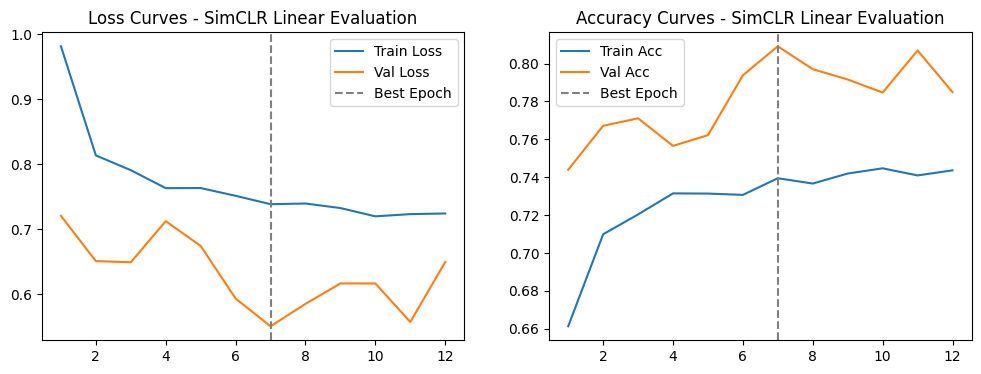

In [41]:
plot_train_curves(results_linear_eval, "SimCLR Linear Evaluation")

In [ ]:
class SimCLRFinetuneModel(nn.Module):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        feats = self.encoder(x)
        return self.classifier(feats)


reproducibility()

simclr_model2 = SimCLR(backbone="resnet34", proj_dim=128).to(device)
simclr_model2.load_state_dict(torch.load("simclr_resnet34_pretrained.pth"))
encoder = simclr_model2.encoder

simclr_fine_tune = SimCLRFinetuneModel(encoder, num_classes).to(device)

optimizer = torch.optim.Adam(simclr_fine_tune.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

results_simclr_full = train_model(
    model=simclr_fine_tune,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=30,
)

Random seed set to 42
Epoch 1/30 | Train Loss: 0.7257, Train Acc: 0.7523 | Val Loss: 0.3820, Val Acc: 0.8662
Epoch 2/30 | Train Loss: 0.4567, Train Acc: 0.8424 | Val Loss: 0.3285, Val Acc: 0.8832
Epoch 3/30 | Train Loss: 0.3915, Train Acc: 0.8647 | Val Loss: 0.3007, Val Acc: 0.9010
Epoch 4/30 | Train Loss: 0.3501, Train Acc: 0.8778 | Val Loss: 0.2631, Val Acc: 0.9101
Epoch 5/30 | Train Loss: 0.3216, Train Acc: 0.8878 | Val Loss: 0.2288, Val Acc: 0.9188
Epoch 6/30 | Train Loss: 0.3029, Train Acc: 0.8951 | Val Loss: 0.2417, Val Acc: 0.9138
Epoch 7/30 | Train Loss: 0.2735, Train Acc: 0.9056 | Val Loss: 0.2170, Val Acc: 0.9259
Epoch 8/30 | Train Loss: 0.2660, Train Acc: 0.9053 | Val Loss: 0.2064, Val Acc: 0.9291
Epoch 9/30 | Train Loss: 0.2554, Train Acc: 0.9119 | Val Loss: 0.2336, Val Acc: 0.9175
Epoch 10/30 | Train Loss: 0.2354, Train Acc: 0.9181 | Val Loss: 0.1958, Val Acc: 0.9301
Epoch 11/30 | Train Loss: 0.2306, Train Acc: 0.9206 | Val Loss: 0.2301, Val Acc: 0.9207
Epoch 12/30 | Train

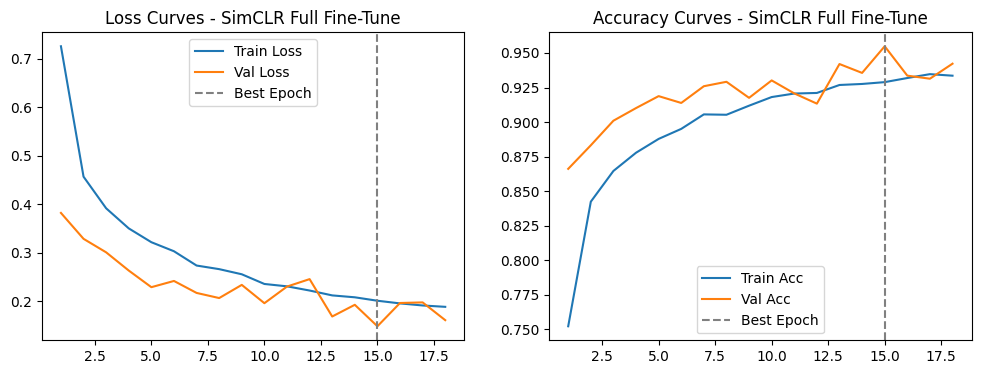

In [45]:
plot_train_curves(results_simclr_full, "SimCLR Full Fine-Tune")

In [ ]:
reproducibility()

simclr_model3 = SimCLR(backbone="resnet34", proj_dim=128).to(device)
simclr_model3.load_state_dict(torch.load("simclr_resnet34_pretrained.pth"))
encoder = simclr_model3.encoder

simclr_fine_tune_10shot = SimCLRFinetuneModel(encoder, num_classes).to(device)

optimizer = torch.optim.Adam(simclr_fine_tune_10shot.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

results_simclr_10shot = train_model(
    model=simclr_fine_tune_10shot,
    train_loader=train_10shot_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=30,
)

Random seed set to 42
Epoch 1/30 | Train Loss: 2.5682, Train Acc: 0.0500 | Val Loss: 2.4294, Val Acc: 0.0664
Epoch 2/30 | Train Loss: 2.4160, Train Acc: 0.0400 | Val Loss: 2.2999, Val Acc: 0.1272
Epoch 3/30 | Train Loss: 2.3127, Train Acc: 0.0700 | Val Loss: 2.2172, Val Acc: 0.1709
Epoch 4/30 | Train Loss: 2.2077, Train Acc: 0.1800 | Val Loss: 2.1540, Val Acc: 0.2007
Epoch 5/30 | Train Loss: 2.1510, Train Acc: 0.2300 | Val Loss: 2.0741, Val Acc: 0.2378
Epoch 6/30 | Train Loss: 2.0225, Train Acc: 0.2700 | Val Loss: 2.0049, Val Acc: 0.3022
Epoch 7/30 | Train Loss: 1.9739, Train Acc: 0.2800 | Val Loss: 1.9527, Val Acc: 0.3452
Epoch 8/30 | Train Loss: 1.8716, Train Acc: 0.4200 | Val Loss: 1.9015, Val Acc: 0.3849
Epoch 9/30 | Train Loss: 1.8499, Train Acc: 0.4200 | Val Loss: 1.8579, Val Acc: 0.4074
Epoch 10/30 | Train Loss: 1.8002, Train Acc: 0.4600 | Val Loss: 1.8181, Val Acc: 0.4252
Epoch 11/30 | Train Loss: 1.7720, Train Acc: 0.4700 | Val Loss: 1.7871, Val Acc: 0.4306
Epoch 12/30 | Train

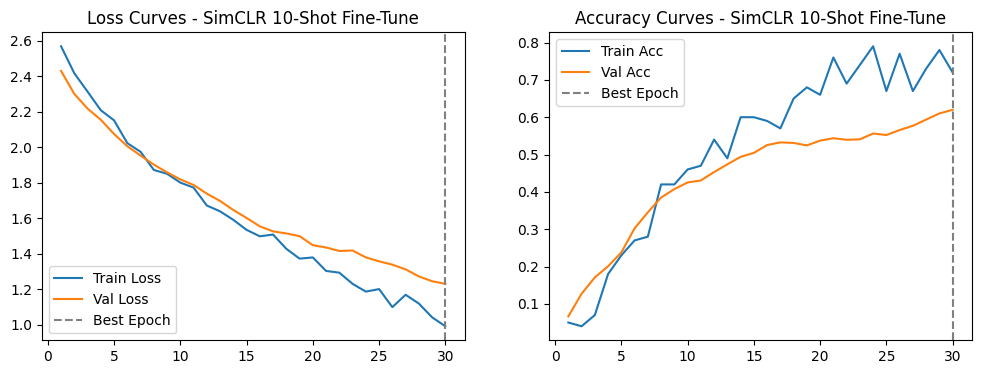

In [57]:
plot_train_curves(results_simclr_10shot, "SimCLR 10-Shot Fine-Tune")

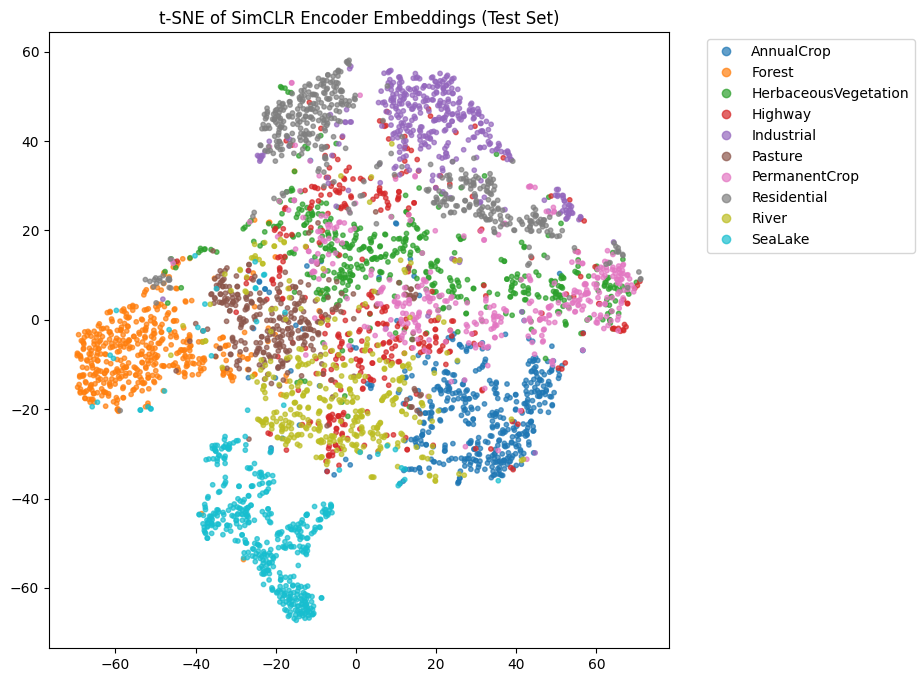

In [ ]:
def extract_embeddings(encoder, dataloader):
    encoder.eval()
    feats, labels = [], []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            h = encoder(x)
            feats.append(h.cpu())
            labels.append(y)

    feats = torch.cat(feats).numpy()
    labels = torch.cat(labels).numpy()

    return feats, labels


simclr_model = SimCLR(backbone="resnet34", proj_dim=128).to(device)
simclr_model.load_state_dict(torch.load("simclr_resnet34_pretrained.pth"))
embeddings, labels = extract_embeddings(simclr_model.encoder, test_loader)

tsne = TSNE(random_state=42)
emb_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    emb_2d[:, 0], emb_2d[:, 1], c=labels, cmap="tab10", s=10, alpha=0.7
)

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

plt.title("t-SNE of SimCLR Encoder Embeddings (Test Set)")
plt.show()